# Nuclear Instrumentation Health Monitoring System

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

We load the Combined Cycle Power Plant data from the .xlsx file. The 
file contains five sheets, each a different random shuffle of the same 
9,568 observations. We use the first sheet for our analysis.

In [6]:
# Read the excel file into a pandas DataFrame and assign it to variable df. 
# The variable df is our primary DataFrame

df = pd.read_excel("../data/Folds5x2_pp.xlsx")

In [7]:
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


## Initial Inspection: Examine Data

In [8]:
# Returns the first 5 rows of the DataFrame.
# Used to see what the data actually looks like — column names, value formats, magnitudes

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [9]:
# Returns the last five rows
# Useful for checking: does the data go all the way to where I expect?

df.tail()

,AT,V,AP,RH,PE
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74
9567,21.60,62.52,1017.23,67.87,453.28


In [10]:
df.shape # Returns tuple 

(9568, 5)

In [11]:
# Returns the list of column names

df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='str')

In [12]:
# Returns the data type of each column.

df.dtypes

AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

In [13]:
# Prints a compact summary: 
# column names, count of non-null values per column, data types, and memory usage. 
# Especially useful for spotting missing data 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [14]:
# Computes summary statistics (count, mean, std, min, 25/50/75 percentiles, max) for every numeric column

df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


## Sensor Distributions

Examine the distribution of each variable before applying statistical methods that assume normality.

In [32]:
columns = ['AT', 'AP', 'RH', 'V', 'PE']

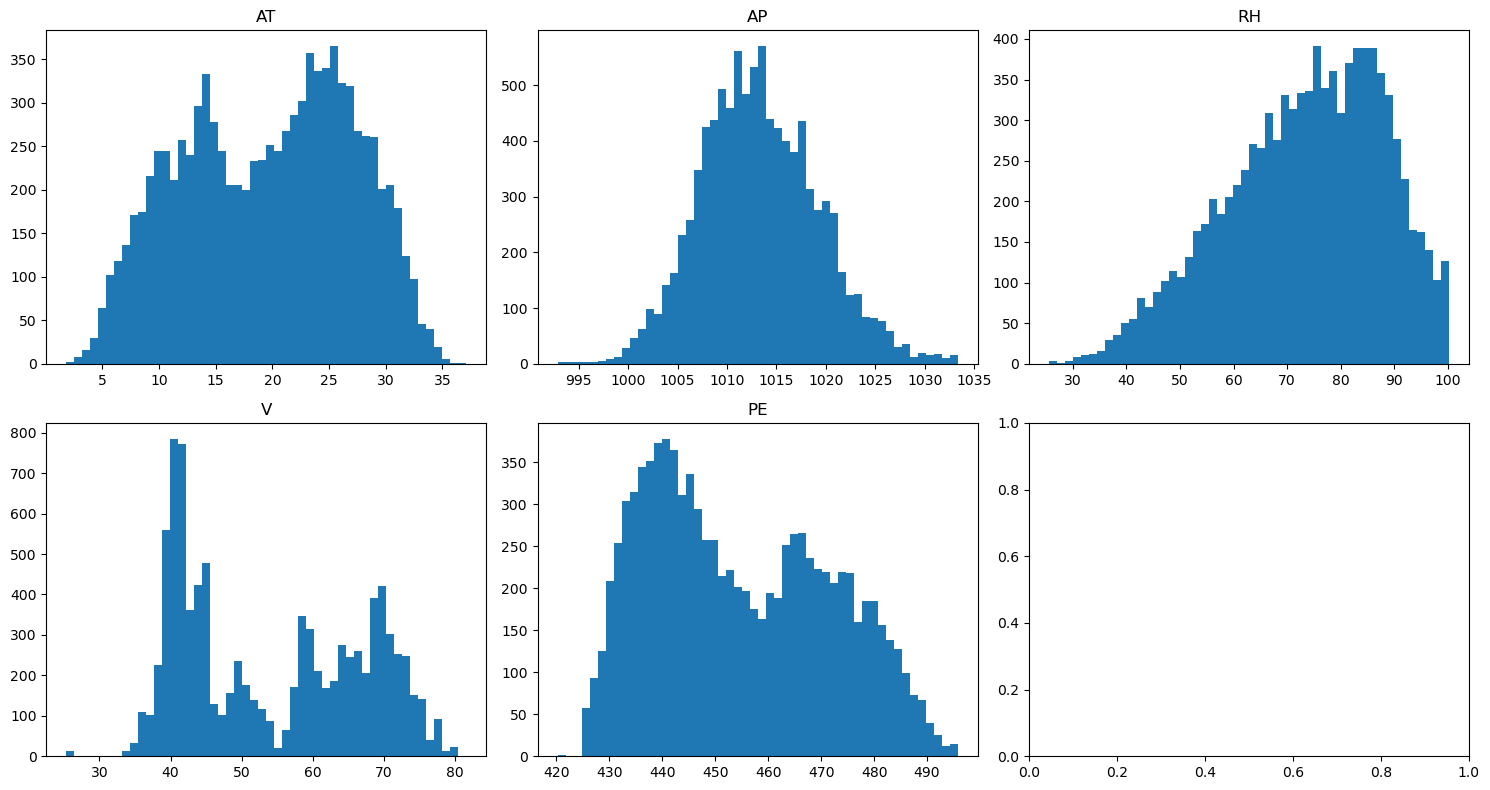

In [41]:
# For multiple plots in a grid, we need to explicitly create a figure with multiple axes and tell each axis what to draw
# We use the function plt.subplots() to return the tuple consisting of a Figure object and an array of Axes objects.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8)) 

# The following creates a 2x3 grid of subplots
axes[0, 0].hist(df['AT'], bins=50)
axes[0, 0].set_title('AT')

axes[0, 1].hist(df['AP'], bins=50)
axes[0, 1].set_title('AP')

axes[0, 2].hist(df['RH'], bins=50)
axes[0, 2].set_title('RH')

axes[1, 0].hist(df['V'], bins=50)
axes[1, 0].set_title('V')

axes[1, 1].hist(df['PE'], bins=50)
axes[1, 1].set_title('PE')

plt.tight_layout()
plt.show()


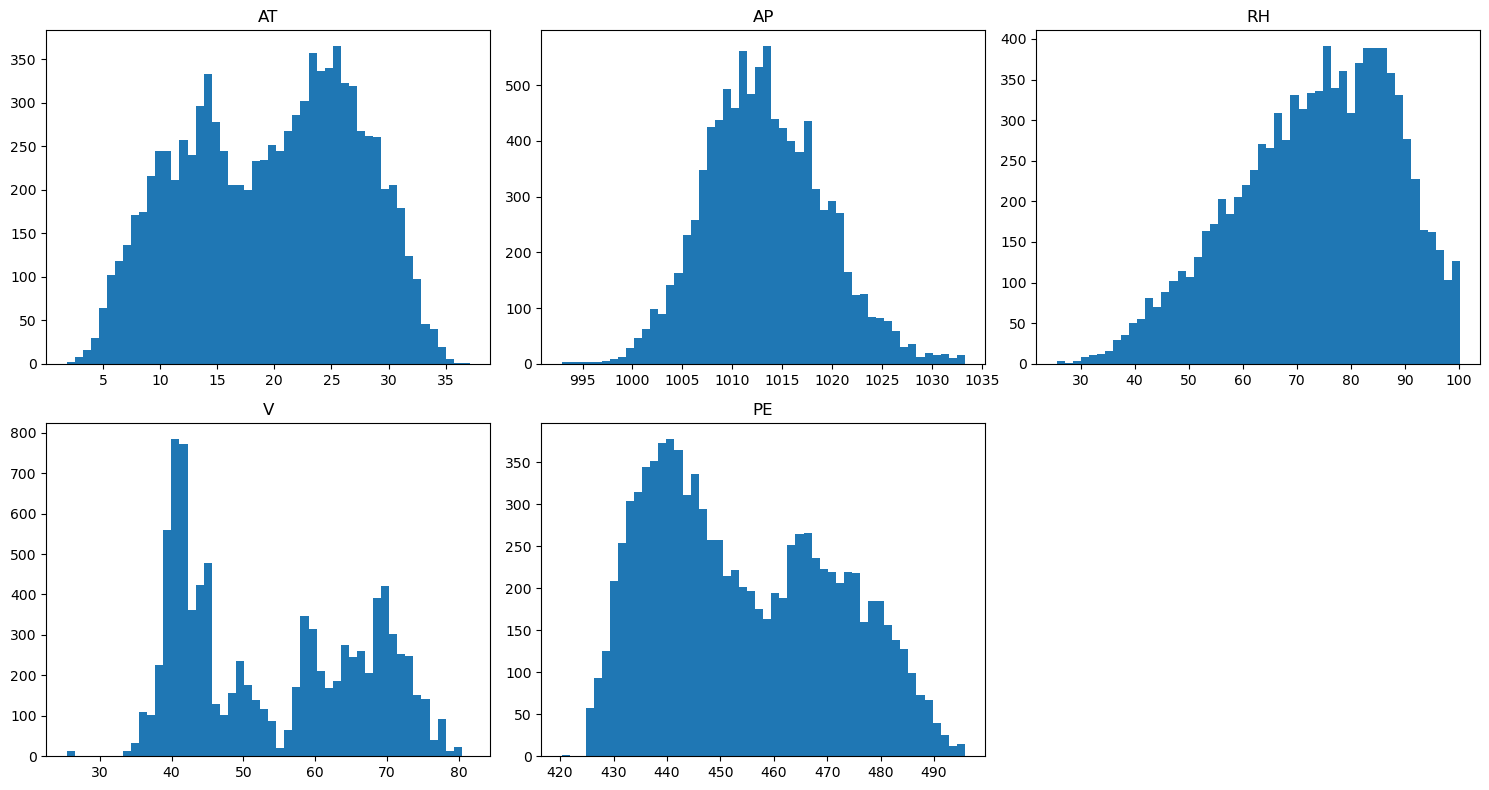

In [45]:
# The following code accomplishes the same thing as the code in [36]
# It's a quicker means for generating the histograms by looping over the columuns list.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8)) 

for ax, col in zip(axes.flatten(), columns):
    ax.hist(df[col], bins=50)
    ax.set_title(col)

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

#  Note that zip() pairs items from 2 sequences. Since axes is a 2D-array, we must convert it into a flat list
# axes.flatten() turns the 2x3 grid into a 1D array of 6 axes. 

## Observations and Interpretations

The previous distributions reflect real, physical processes based on the sensor data. Let's go through each plot:

I) Ambient Temperature (AT): The plot has two distinct humps, indicating that it has a bimodal distribution. Seasonal weather and climate is the best physical explanation for this distribution.

II) Ambient Pressure (AP): Roughly symmetric and with a single peak, this plot most closely resembles a Gaussian, or normal, distribution. Atmospheric pressure constantly fluctuates around a localized, long-term mean.

III) Relative Humidity (RH): Strongly left-skewed where the bulk of the data is on the high end (70–90%), with a long tail trailing toward lower humidity values. 

IV) Exhaust Vacuum (V): With three to four distinguishable peaks, the plot is strongly multimodal. Since V is determined by the operating state of the steam turbine, which depends on load conditions, ambient temperature, and cooling system performance, the multiple modes likely reflect specific plant operations. 

V) Net Electrical Power Output (PE): Bimodal with two clear peaks. Note the similarities between the plot for AT and the plot for PE. 